# Neural unit response analysis

This notebook analyzes unit-level firing-rate response classifications in the mouse insular cortex.

The analysis compares neural units recorded in two experimental groups:

- **Saline**: control animals injected with saline solution.
- **5-Meo**: animals injected with 5-MeO-DMT.

Each recorded unit is classified according to its mean post-injection firing-rate modulation using a Z-score threshold:

- `excited`: increased firing activity, Z-score > +2.58.
- `inhibited`: decreased firing activity, Z-score < -2.58.
- `no_change`: no significant modulation, -2.58 ≤ Z-score ≤ +2.58.

The threshold ±2.58 corresponds approximately to a two-tailed threshold of p < 0.01 under a standard normal assumption.

This notebook also uses the output of the previous notebook, **`01_waveform_clustering.ipynb`**, which assigns each unit to a waveform-based cluster. These clusters are used here to split 5-MeO units into putative GABA and putative GLUT populations.

## 1. Imports and global settings

In [12]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from matplotlib.lines import Line2D

os.makedirs("figures", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

# Global label conventions used throughout the notebook.
GROUP_ORDER = ["Saline", "5-Meo"]
STATUS_ORDER = ["excited", "inhibited", "no_change"]

STATUS_COLORS = {
    "excited": "#c92335",
    "inhibited": "#4f61b1",
    "no_change": "#d8dee9",
}

STATUS_LABELS = {
    "excited": "Excited",
    "inhibited": "Inhibited",
    "no_change": "No Change",
}

Z_THRESHOLD = 2.58
Z_COL = "zscore_mean_after"


def find_existing_file(candidates):
    """Return the first existing path among candidate paths."""
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(
        "None of the candidate files were found:\n" +
        "\n".join(str(c) for c in candidates)
    )


def normalize_unit_id(series):
    """Standardize unit identifiers to strings and remove trailing .0 when present."""
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


def clean_group_labels(series):
    """Harmonize group names across notebooks and CSV files."""
    return (
        series.astype(str)
        .str.strip()
        .replace({
            "5-MeO": "5-Meo",
            "5-MEO": "5-Meo",
            "5-meo": "5-Meo",
            "5meo": "5-Meo",
            "5-MeO-DMT": "5-Meo",
            "saline": "Saline",
            "SALINE": "Saline",
            "Saline ": "Saline",
        })
    )


def clean_response_labels(series):
    """Harmonize response labels so that no_change is always written with underscore."""
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .replace({
            "nochange": "no_change",
            "unchanged": "no_change",
            "not_modulated": "no_change",
            "non_modulated": "no_change",
            "decreased": "inhibited",
            "decreased_firing": "inhibited",
            "decreased_firing_unit": "inhibited",
            "increased": "excited",
            "increased_firing": "excited",
            "increased_firing_unit": "excited",
        })
    )


def autopct_format(pct):
    """French-style percentage label for pie charts."""
    if pct < 0.1:
        return ""
    return f"{pct:.1f}%".replace(".", ",")

## 2. Load and clean the response-classification dataset

The response-classification table is expected to contain one row per recorded unit.

Expected conceptual columns are:

- mouse identifier,
- experimental group,
- unit identifier,
- mean post-injection Z-score,
- response status.

The code below renames common column variants to a standardized format and stores the cleaned complete dataset 

In [13]:
DATA_PATH = find_existing_file([
    "data/processed/unit_classification_all_mice.csv",
    "unit_classification_all_mice.csv",
])

print(f"Loading response-classification data from: {DATA_PATH}")

df_all = pd.read_csv(DATA_PATH)

# Standardize column names used in previous scripts/notebooks.
df_all = df_all.rename(columns={
    "Mouse": "mouse_id",
    "mouse": "mouse_id",
    "Group": "group",
    "Unit": "unit_id",
    "unit": "unit_id",
    "Zscore_mean_after": "zscore_mean_after",
    "zscore_after": "zscore_mean_after",
    "Status": "response_status",
    "status": "response_status",
})

required_columns = ["mouse_id", "group", "unit_id", "zscore_mean_after", "response_status"]
missing_columns = [col for col in required_columns if col not in df_all.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}\nAvailable columns: {df_all.columns.tolist()}")

# Clean critical columns.
df_all["mouse_id"] = df_all["mouse_id"].astype(str).str.strip()
df_all["unit_id"] = normalize_unit_id(df_all["unit_id"])
df_all["group"] = clean_group_labels(df_all["group"])
df_all["response_status"] = clean_response_labels(df_all["response_status"])
df_all["zscore_mean_after"] = pd.to_numeric(df_all["zscore_mean_after"], errors="coerce")

# Keep response status as simple strings for plotting and merging.
# Do not convert to Categorical here: it can hide label mismatches during debugging.

print("Dataset shape:", df_all.shape)
display(df_all.head())

Loading response-classification data from: data\processed\unit_classification_all_mice.csv
Dataset shape: (602, 5)


,mouse_id,group,unit_id,zscore_mean_after,response_status
0,F3876,Saline,58,-1.481,no_change
1,F3876,Saline,66,-0.112,no_change
2,F3876,Saline,72,-0.648,no_change
3,F3876,Saline,80,-0.855,no_change
4,F3876,Saline,104,0.353,no_change


## 3. Sanity checks

In [14]:
print("Columns:")
print(df_all.columns.tolist())

print("\nMissing values:")
display(df_all[required_columns].isna().sum())

print("\nGroups:")
display(df_all["group"].value_counts())

print("\nResponse statuses:")
display(df_all["response_status"].value_counts())

unknown_statuses = sorted(set(df_all["response_status"].dropna()) - set(STATUS_ORDER))
unknown_groups = sorted(set(df_all["group"].dropna()) - set(GROUP_ORDER))

if unknown_statuses:
    print("WARNING - unknown response statuses:", unknown_statuses)
if unknown_groups:
    print("WARNING - unknown groups:", unknown_groups)

Columns:
['mouse_id', 'group', 'unit_id', 'zscore_mean_after', 'response_status']

Missing values:


mouse_id             0
group                0
unit_id              0
zscore_mean_after    0
response_status      0
dtype: int64


Groups:


group
5-Meo     361
Saline    241
Name: count, dtype: int64


Response statuses:


response_status
no_change    374
inhibited    205
excited       23
Name: count, dtype: int64

## 4. Response-status counts and percentages by group

In [15]:
counts = (
    df_all.groupby(["group", "response_status"], observed=False)
    .size()
    .reset_index(name="n_units")
)

# Enforce clean display order.
counts["group"] = pd.Categorical(counts["group"], categories=GROUP_ORDER, ordered=True)
counts["response_status"] = pd.Categorical(counts["response_status"], categories=STATUS_ORDER, ordered=True)
counts = counts.sort_values(["group", "response_status"]).reset_index(drop=True)

proportions = counts.copy()
proportions["percentage"] = (
    proportions["n_units"]
    / proportions.groupby("group", observed=False)["n_units"].transform("sum")
    * 100
)

display(counts)
display(proportions)

summary_table = pd.crosstab(
    df_all["group"],
    df_all["response_status"],
    margins=True
)

summary_percent = pd.crosstab(
    df_all["group"],
    df_all["response_status"],
    normalize="index"
) * 100

summary_percent = summary_percent.reindex(
    index=[g for g in GROUP_ORDER if g in summary_percent.index],
    columns=STATUS_ORDER,
    fill_value=0,
)

print("Raw counts:")
display(summary_table)

print("Percentages:")
display(summary_percent.round(1))

,group,response_status,n_units
0,Saline,excited,2
1,Saline,no_change,239
2,5-Meo,excited,21
3,5-Meo,inhibited,205
4,5-Meo,no_change,135


,group,response_status,n_units,percentage
0,Saline,excited,2,0.829876
1,Saline,no_change,239,99.170124
2,5-Meo,excited,21,5.817175
3,5-Meo,inhibited,205,56.786704
4,5-Meo,no_change,135,37.396122


Raw counts:


response_status,excited,inhibited,no_change,All
group,,,,
5-Meo,21,205,135,361
Saline,2,0,239,241
All,23,205,374,602


Percentages:


response_status,excited,inhibited,no_change
group,,,
Saline,0.8,0.0,99.2
5-Meo,5.8,56.8,37.4


## 5. Figure F — Proportion of modulated units by group

This figure summarizes the proportion of units classified as excited, inhibited, or unchanged in each experimental group.

The figure is designed as a final-panel version rather than an exploratory barplot.


Saline
response_status
excited        2
inhibited      0
no_change    239
Name: count, dtype: int64
Total: 241

5-Meo
response_status
excited       21
inhibited    205
no_change    135
Name: count, dtype: int64
Total: 361


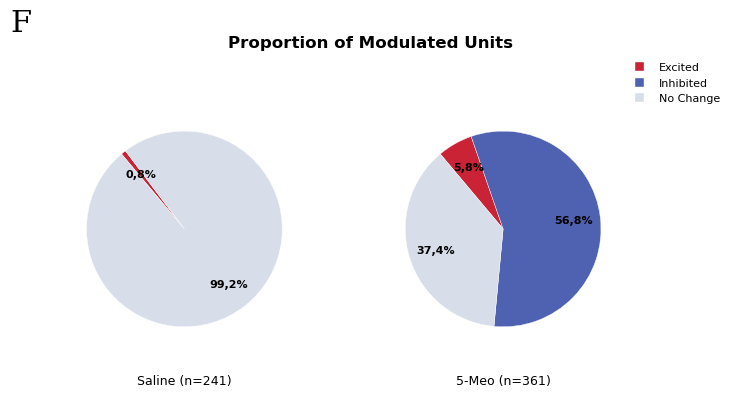

In [16]:
group_order = [g for g in GROUP_ORDER if g in df_all["group"].unique()]

fig, axes = plt.subplots(1, len(group_order), figsize=(7.5, 4.2))
if len(group_order) == 1:
    axes = [axes]

fig.suptitle(
    "Proportion of Modulated Units",
    fontsize=12,
    fontweight="bold",
    y=0.92,
)

for ax, group in zip(axes, group_order):
    subset = df_all[df_all["group"] == group]

    pie_counts = (
        subset["response_status"]
        .value_counts()
        .reindex(STATUS_ORDER, fill_value=0)
    )

    print(f"\n{group}")
    print(pie_counts)
    print("Total:", pie_counts.sum())

    if pie_counts.sum() == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        continue

    ax.pie(
        pie_counts.values,
        colors=[STATUS_COLORS[s] for s in STATUS_ORDER],
        startangle=130,
        counterclock=False,
        autopct=autopct_format,
        pctdistance=0.72,
        textprops={"fontsize": 8, "fontweight": "bold", "color": "black"},
        wedgeprops={"linewidth": 0.3, "edgecolor": "white"},
    )

    ax.set_title(
        f"{group} (n={pie_counts.sum()})",
        fontsize=9,
        y=-0.12,
    )
    ax.axis("equal")

legend_handles = [
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        label=STATUS_LABELS[status],
        markerfacecolor=STATUS_COLORS[status],
        markersize=7,
    )
    for status in STATUS_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),
    frameon=False,
    fontsize=8,
)

fig.text(0.02, 0.93, "F", fontsize=22, fontweight="normal", family="serif")

plt.tight_layout(rect=[0.03, 0.03, 0.90, 0.88])
plt.savefig("figures/response_status_pie_by_group.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

Interpretation :

This figure summarizes the proportion of units classified as excited, inhibited, or unchanged in each experimental group. Compared with saline-treated animals, the 5-MeO-DMT group appears to contain a larger proportion of modulated units, suggesting that the injection induces a broader alteration of neuronal firing activity in the insular cortex.

However, this representation is descriptive: it shows the relative distribution of response categories, but does not by itself establish whether the difference between groups is statistically significant.

## 6. Figure E — Z-score distribution by group

The histogram previously used in this notebook was useful as a quick quality-control plot, but it is less clear for final presentation.  
The figure below shows the full distribution of unit-level post-injection Z-scores using violin plots and individual jittered points.

Point colors indicate response classification relative to the ±2.58 threshold:

- red: increased-firing unit,
- blue: decreased-firing unit,
- dark gray: no change.

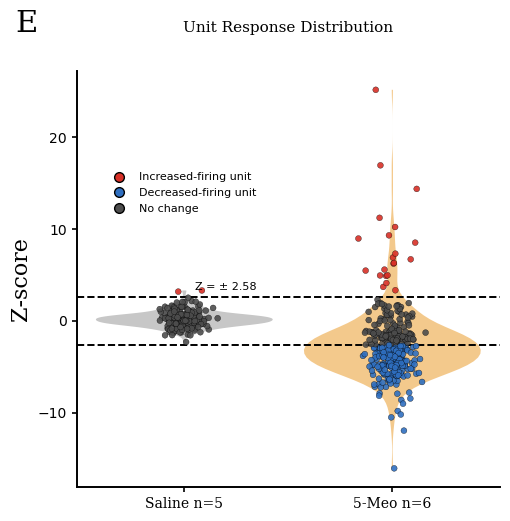

In [17]:
group_order = [g for g in GROUP_ORDER if g in df_all["group"].unique()]

color_increased = "#d73027"
color_decreased = "#2f6fc0"
color_nochange = "#4d4d4d"

violin_colors = {
    "Saline": "#bdbdbd",
    "5-Meo": "#f2c078",
}

fig, ax = plt.subplots(figsize=(5.2, 5.2))

# Data for violin plots. Empty groups are not plotted.
data_to_plot = [
    df_all[df_all["group"] == group][Z_COL].dropna().values
    for group in group_order
]

positions = np.arange(1, len(group_order) + 1)

violins = ax.violinplot(
    data_to_plot,
    positions=positions,
    widths=0.85,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)

for body, group in zip(violins["bodies"], group_order):
    body.set_facecolor(violin_colors.get(group, "#cccccc"))
    body.set_edgecolor("none")
    body.set_alpha(0.85)

# Individual unit points.
rng = np.random.default_rng(42)

for i, group in enumerate(group_order, start=1):
    subset = df_all[df_all["group"] == group].dropna(subset=[Z_COL]).copy()

    y = subset[Z_COL].values
    x = rng.normal(loc=i, scale=0.055, size=len(subset))

    point_colors = np.where(
        y > Z_THRESHOLD,
        color_increased,
        np.where(y < -Z_THRESHOLD, color_decreased, color_nochange),
    )

    ax.scatter(
        x,
        y,
        c=point_colors,
        s=18,
        alpha=0.9,
        edgecolor="black",
        linewidth=0.25,
        zorder=3,
    )

# Threshold lines.
ax.axhline(Z_THRESHOLD, linestyle="--", linewidth=1.4, color="black")
ax.axhline(-Z_THRESHOLD, linestyle="--", linewidth=1.4, color="black")

# Place the threshold annotation near the first group if possible.
if len(group_order) > 0:
    ax.text(
        positions[0] + 0.05,
        Z_THRESHOLD + 0.55,
        "Z = ± 2.58",
        fontsize=8,
        ha="left",
        va="bottom",
    )

# X labels use number of mice, not number of units.
xtick_labels = []
for group in group_order:
    subset = df_all[df_all["group"] == group]
    n_mice = subset["mouse_id"].nunique() if "mouse_id" in subset.columns else np.nan
    xtick_labels.append(f"{group} n={n_mice}")

ax.set_xticks(positions)
ax.set_xticklabels(xtick_labels, fontsize=14, family="serif")

ax.set_ylabel("Z-score", fontsize=16, family="serif")
ax.set_title("Unit Response Distribution", fontsize=11, family="serif", pad=28)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Increased-firing unit",
           markerfacecolor=color_increased, markeredgecolor="black", markersize=7),
    Line2D([0], [0], marker="o", color="w", label="Decreased-firing unit",
           markerfacecolor=color_decreased, markeredgecolor="black", markersize=7),
    Line2D([0], [0], marker="o", color="w", label="No change",
           markerfacecolor=color_nochange, markeredgecolor="black", markersize=7),
]

ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.05, 0.78), frameon=False, fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.4)
ax.spines["bottom"].set_linewidth(1.4)
ax.tick_params(axis="both", width=1.2, labelsize=10)

fig.text(0.04, 0.95, "E", fontsize=22, family="serif")

plt.tight_layout()
plt.savefig("figures/zscore_distribution_violin_by_group.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

Interpretation :

The violin plot shows the distribution of mean post-injection firing-rate Z-scores across units in each group. Individual points represent single units, while the dashed horizontal lines indicate the ±2.58 classification thresholds used to define significantly increased or decreased firing.

Compared with the saline group, the 5-MeO-DMT group shows a broader distribution of Z-scores, with more units crossing the positive and/or negative modulation thresholds. This suggests that 5-MeO-DMT does not simply shift the population uniformly in one direction, but rather increases the heterogeneity of neuronal responses, with some units increasing and others decreasing their firing rate after injection.

## 7. Chi-square test on response-status distribution

A chi-square test is used to assess whether the distribution of response statuses differs between experimental groups.

The contingency table compares the number of units classified as excited, inhibited, or no change across groups.

In [19]:
contingency_table = pd.crosstab(
    df_all["group"],
    df_all["response_status"]
).reindex(
    index=[g for g in GROUP_ORDER if g in df_all["group"].unique()],
    columns=STATUS_ORDER,
    fill_value=0,
)

display(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.3e}")

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns,
)

print("\nExpected counts under independence:")
display(expected_df.round(2))

response_status,excited,inhibited,no_change
group,,,
Saline,2,0,239
5-Meo,21,205,135


Chi-square statistic: 235.034
Degrees of freedom: 2
P-value: 9.183e-52

Expected counts under independence:


response_status,excited,inhibited,no_change
group,,,
Saline,9.21,82.07,149.72
5-Meo,13.79,122.93,224.28


Chi-square test interpretation :

A chi-square test of independence was used to assess whether the distribution of response categories differed between experimental groups. The test indicated a significant association between treatment group and response status, suggesting that the proportion of excited, inhibited, and unchanged units is not equivalent between saline- and 5-MeO-DMT-treated animals.

This supports the idea that 5-MeO-DMT modifies the population-level distribution of firing-rate responses in the insular cortex.

## 9. Link with previous waveform-clustering notebook

The previous notebook, **`01_waveform_clustering.ipynb`**, generates a CSV file named **`unit_waveform_clusters.csv`**.

This file contains one row per unit with a waveform-based cluster assignment. Here, that cluster assignment is merged with the response-classification table using:

- `mouse_id`,
- `group`,
- `unit_id`.

The goal is to examine, within the **5-Meo** group only, whether putative GABA and putative GLUT units show different response-status proportions.

By default, the mapping used here is:

- cluster `1` → putative GABA units,
- cluster `0` → putative GLUT units.

If your waveform interpretation changes, invert the `CLUSTER_LABELS` dictionary below.

In [20]:
CLUSTER_PATH = find_existing_file([
    "data/processed/unit_waveform_clusters.csv",
    "unit_waveform_clusters.csv",
])

print(f"Loading waveform-clustering data from: {CLUSTER_PATH}")

clusters = pd.read_csv(CLUSTER_PATH)

required_cluster_columns = ["mouse_id", "group", "unit_id", "cluster"]
missing_cluster_columns = [col for col in required_cluster_columns if col not in clusters.columns]
if missing_cluster_columns:
    raise ValueError(
        f"Missing required cluster columns: {missing_cluster_columns}\n"
        f"Available columns: {clusters.columns.tolist()}"
    )

clusters["mouse_id"] = clusters["mouse_id"].astype(str).str.strip()
clusters["unit_id"] = normalize_unit_id(clusters["unit_id"])
clusters["group"] = clean_group_labels(clusters["group"])
clusters["cluster"] = pd.to_numeric(clusters["cluster"], errors="coerce").astype("Int64")

print("Cluster file shape:", clusters.shape)
print("\nCluster groups:")
display(clusters["group"].value_counts())
print("\nCluster labels:")
display(clusters["cluster"].value_counts(dropna=False).sort_index())

df_clustered = df_all.merge(
    clusters[["mouse_id", "group", "unit_id", "cluster"]],
    on=["mouse_id", "group", "unit_id"],
    how="inner",
)

print("Response data shape:", df_all.shape)
print("Merged data shape:", df_clustered.shape)
print(f"Merge coverage: {len(df_clustered) / len(df_all) * 100:.1f}% of response-classified units")

if len(df_clustered) < len(df_all):
    print("WARNING: Some response-classified units were not matched to waveform clusters.")
    unmatched = df_all.merge(
        clusters[["mouse_id", "group", "unit_id", "cluster"]],
        on=["mouse_id", "group", "unit_id"],
        how="left",
        indicator=True,
    )
    display(unmatched[unmatched["_merge"] == "left_only"][["mouse_id", "group", "unit_id"]].head(20))

print("\nMerged counts by group, cluster and response status:")
display(
    df_clustered[["group", "cluster", "response_status"]]
    .value_counts()
    .sort_index()
    .rename("n_units")
    .reset_index()
)

Loading waveform-clustering data from: data\processed\unit_waveform_clusters.csv
Cluster file shape: (581, 14)

Cluster groups:


group
5-Meo     348
Saline    233
Name: count, dtype: int64


Cluster labels:


cluster
0    410
1    171
Name: count, dtype: Int64

Response data shape: (602, 5)
Merged data shape: (581, 6)
Merge coverage: 96.5% of response-classified units


,mouse_id,group,unit_id
46,F3878,Saline,182
55,F3878,Saline,256
182,F3800,Saline,156
225,F3797,5-Meo,92
226,F3797,5-Meo,94
227,F3797,5-Meo,96
236,F3797,5-Meo,143
238,F3797,5-Meo,149
247,F3797,5-Meo,187
248,F3797,5-Meo,191



Merged counts by group, cluster and response status:


,group,cluster,response_status,n_units
0,5-Meo,0,excited,18
1,5-Meo,0,inhibited,137
2,5-Meo,0,no_change,87
3,5-Meo,1,excited,2
4,5-Meo,1,inhibited,64
5,5-Meo,1,no_change,40
6,Saline,0,excited,1
7,Saline,0,no_change,167
8,Saline,1,no_change,65


## 10. Figure — 5-Meo response proportions by putative cell type

5-Meo clustered units: (348, 7)

Cell-type counts:


cell_type
Putative GLUT Units    242
Putative GABA Units    106
Name: count, dtype: int64


Putative GABA Units
response_status
excited       2
inhibited    64
no_change    40
Name: count, dtype: int64
Total: 106

Putative GLUT Units
response_status
excited       18
inhibited    137
no_change     87
Name: count, dtype: int64
Total: 242


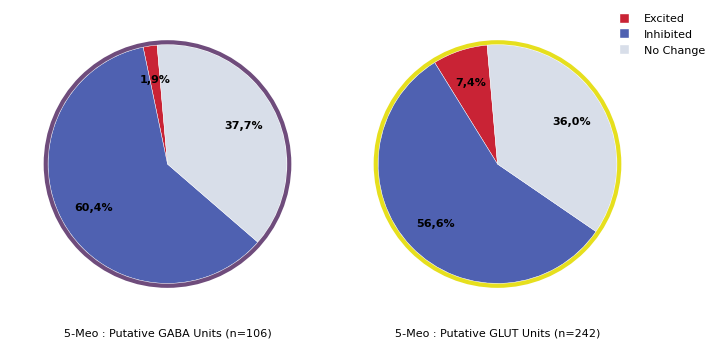

In [21]:
# Adjust this mapping if the biological interpretation of your waveform clusters changes.
CLUSTER_LABELS = {
    1: "Putative GABA Units",
    0: "Putative GLUT Units",
}

CELLTYPE_ORDER = [
    "Putative GABA Units",
    "Putative GLUT Units",
]

df_5meo_clustered = df_clustered[df_clustered["group"] == "5-Meo"].copy()
df_5meo_clustered["cell_type"] = df_5meo_clustered["cluster"].map(CLUSTER_LABELS)

print("5-Meo clustered units:", df_5meo_clustered.shape)
print("\nCell-type counts:")
display(df_5meo_clustered["cell_type"].value_counts(dropna=False))

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))

# Colored outlines to visually separate the putative cell types.
outline_colors = {
    "Putative GABA Units": "#6f4c7c",
    "Putative GLUT Units": "#e6df1e",
}

for ax, cell_type in zip(axes, CELLTYPE_ORDER):
    subset = df_5meo_clustered[df_5meo_clustered["cell_type"] == cell_type]

    pie_counts = (
        subset["response_status"]
        .value_counts()
        .reindex(STATUS_ORDER, fill_value=0)
    )

    print(f"\n{cell_type}")
    print(pie_counts)
    print("Total:", pie_counts.sum())

    if pie_counts.sum() == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        continue

    wedges, texts, autotexts = ax.pie(
        pie_counts.values,
        colors=[STATUS_COLORS[s] for s in STATUS_ORDER],
        startangle=95,
        counterclock=True,
        autopct=autopct_format,
        pctdistance=0.72,
        textprops={"fontsize": 8, "fontweight": "bold", "color": "black"},
        wedgeprops={"linewidth": 0.3, "edgecolor": "white"},
    )

    # Add an external outline circle, matching the example figure style.
    outline = plt.Circle(
        (0, 0),
        1.02,
        transform=ax.transData,
        fill=False,
        linewidth=3,
        edgecolor=outline_colors.get(cell_type, "black"),
    )
    ax.add_artist(outline)

    ax.set_title(
        f"5-Meo : {cell_type} (n={pie_counts.sum()})",
        fontsize=8,
        y=-0.12,
    )
    ax.axis("equal")

legend_handles = [
    Line2D([0], [0], marker="s", color="w", label=STATUS_LABELS[status],
           markerfacecolor=STATUS_COLORS[status], markersize=7)
    for status in STATUS_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.95),
    frameon=False,
    fontsize=8,
)

plt.tight_layout(rect=[0.02, 0.03, 0.92, 0.95])
plt.savefig("figures/response_status_5meo_by_putative_celltype.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

Interpretation :

This analysis focuses only on units recorded in the 5-MeO-DMT group and separates them according to their putative electrophysiological identity, inferred from waveform-based clustering in the previous notebook.

The figure compares the proportion of excited, inhibited, and unchanged units between putative GABAergic and putative glutamatergic populations. This allows us to explore whether the effect of 5-MeO-DMT is distributed similarly across electrophysiologically distinct unit classes, or whether one putative cell type appears more strongly modulated.

Because the GABA/GLUT labels are inferred from waveform features rather than directly validated molecular identity, these results should be interpreted as putative cell-type trends rather than definitive cell-type-specific effects.

## 11. Export summary tables

In [22]:
response_summary_path = "data/processed/response_summary_by_group.csv"
cluster_summary_path = "data/processed/response_summary_5meo_by_putative_celltype.csv"

proportions.to_csv(response_summary_path, index=False)

if "df_5meo_clustered" in globals():
    cluster_summary = (
        df_5meo_clustered
        .groupby(["cell_type", "response_status"], observed=False)
        .size()
        .reset_index(name="n_units")
    )
    cluster_summary["percentage"] = (
        cluster_summary["n_units"]
        / cluster_summary.groupby("cell_type", observed=False)["n_units"].transform("sum")
        * 100
    )
    cluster_summary.to_csv(cluster_summary_path, index=False)
    display(cluster_summary)

print(f"Saved: {response_summary_path}")
if "df_5meo_clustered" in globals():
    print(f"Saved: {cluster_summary_path}")

,cell_type,response_status,n_units,percentage
0,Putative GABA Units,excited,2,1.886792
1,Putative GABA Units,inhibited,64,60.377358
2,Putative GABA Units,no_change,40,37.735849
3,Putative GLUT Units,excited,18,7.438017
4,Putative GLUT Units,inhibited,137,56.611570
5,Putative GLUT Units,no_change,87,35.950413


Saved: data/processed/response_summary_by_group.csv
Saved: data/processed/response_summary_5meo_by_putative_celltype.csv


## Conclusion

This notebook shows that neural response profiles differ strongly between experimental groups.

The main result is a clear shift in the proportion of inhibited units in the 5-MeO-DMT group compared with the saline control group.

This analysis demonstrates:
1. Load and standardize the full response-classification dataset .
2. Compare response-status proportions between Saline and 5-Meo groups.
3. Show the full unit-level Z-score distribution using violin plots and individual points.
4. Test categorical response-status differences using a chi-square test.
5. Merge response classifications with waveform clusters from the previous notebook.
6. Split 5-Meo units into putative GABA and putative GLUT populations for additional response-proportion visualization.

Overall, the descriptive figures suggest that 5-MeO-DMT is associated with a broader distribution of firing-rate responses compared with saline, with a larger fraction of units showing marked increases or decreases in activity. This supports the interpretation that 5-MeO-DMT induces heterogeneous modulation of insular cortex neuronal activity rather than a uniform population-wide increase or decrease.

The chi-square analysis formally tests whether response-category proportions differ between groups. This statistical result should be interpreted together with the descriptive plots, as the biological effect may involve both changes in category proportions and changes in the spread of firing-rate modulation.

Finally, the integration with waveform-based clustering allows a preliminary comparison between putative GABAergic and putative glutamatergic units within the 5-MeO-DMT group. These exploratory results may help identify whether specific electrophysiological unit classes are preferentially modulated, but they remain putative because waveform-based classification does not provide direct molecular identification.

Together with the waveform clustering notebook, this provides a compact and reproducible analysis of processed neural single-unit data